In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pratyushakar/rossmann-store-sales/store.csv
/kaggle/input/datasets/pratyushakar/rossmann-store-sales/train.csv
/kaggle/input/datasets/pratyushakar/rossmann-store-sales/test.csv


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)


In [3]:
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)


In [4]:
companies = pd.DataFrame(columns=['company_id', 'company_name'])
products = pd.DataFrame(columns=['product_id', 'product_name', 'company_id'])
purchases = pd.DataFrame(columns=['purchase_id', 'product_id', 'quantity', 'unit_price', 'date'])
sales = pd.DataFrame(columns=['sale_id', 'product_id', 'quantity', 'unit_price', 'date'])

_counters = {'company': 0, 'product': 0, 'purchase': 0, 'sale': 0}


In [5]:
def add_company(name):
    global companies, _counters
    existing = companies[companies['company_name'] == name]
    if not existing.empty:
        return existing.iloc[0]['company_id']
    _counters['company'] += 1
    cid = _counters['company']
    companies.loc[len(companies)] = [cid, name]
    return cid

def add_product(name, company_name):
    global products, _counters
    company_id = add_company(company_name)
    existing = products[(products['product_name'] == name) & (products['company_id'] == company_id)]
    if not existing.empty:
        return existing.iloc[0]['product_id']
    _counters['product'] += 1
    pid = _counters['product']
    products.loc[len(products)] = [pid, name, company_id]
    return pid

def record_purchase(product_name, company_name, quantity, unit_price, date=None):
    global purchases, _counters
    product_id = add_product(product_name, company_name)
    _counters['purchase'] += 1
    purchases.loc[len(purchases)] = [_counters['purchase'], product_id, quantity, unit_price, date or datetime.today().date()]

def record_sale(product_name, company_name, quantity, unit_price, date=None):
    global sales, _counters
    product_id = add_product(product_name, company_name)
    _counters['sale'] += 1
    sales.loc[len(sales)] = [_counters['sale'], product_id, quantity, unit_price, date or datetime.today().date()]


In [6]:
def build_report():
    merged_purchases = purchases.merge(products, on='product_id').merge(companies, on='company_id')
    merged_sales = sales.merge(products, on='product_id').merge(companies, on='company_id')

    bought = merged_purchases.groupby(['product_name', 'company_name']).agg(
        total_purchased_qty=('quantity', 'sum'),
        total_purchase_cost=('quantity', lambda q: (q * merged_purchases.loc[q.index, 'unit_price']).sum())
    )
    sold = merged_sales.groupby(['product_name', 'company_name']).agg(
        total_sold_qty=('quantity', 'sum'),
        total_sale_revenue=('quantity', lambda q: (q * merged_sales.loc[q.index, 'unit_price']).sum())
    )

    report = bought.join(sold, how='outer').fillna(0)
    report['remaining_stock'] = report['total_purchased_qty'] - report['total_sold_qty']
    report['profit'] = report['total_sale_revenue'] - (report['total_sold_qty'] * (report['total_purchase_cost'] / report['total_purchased_qty'].replace(0, np.nan)))
    report['profit'] = report['profit'].fillna(0)
    return report.reset_index()

report = build_report()
display(report)

print('--- OVERALL TOTALS ---')
print('Total spent buying:', report['total_purchase_cost'].sum())
print('Total earned selling:', report['total_sale_revenue'].sum())
print('Total profit:', report['profit'].sum())


,product_name,company_name,total_purchased_qty,total_purchase_cost,total_sold_qty,total_sale_revenue,remaining_stock,profit


--- OVERALL TOTALS ---
Total spent buying: 0
Total earned selling: 0
Total profit: 0


MAE on test set: 2.0211128749921854
Forecast for next 7 days: [39.5 39.6 39.7 39.8 39.9 40.  40.2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


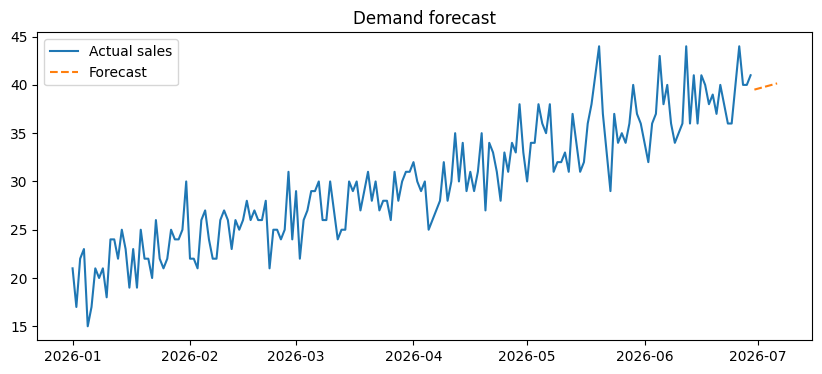

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Simulated daily sales history for one product (replace with real data: date, quantity_sold)
rng = np.random.default_rng(42)
days = pd.date_range('2026-01-01', periods=180)
trend = np.linspace(20, 40, len(days))
noise = rng.normal(0, 3, len(days))
daily_sales = pd.DataFrame({'date': days, 'quantity_sold': (trend + noise).clip(min=0).round()})

daily_sales['day_index'] = np.arange(len(daily_sales))
X = daily_sales[['day_index']]
y = daily_sales['quantity_sold']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)
print('MAE on test set:', mean_absolute_error(y_test, preds))

# Forecast next 7 days
future_idx = np.arange(len(daily_sales), len(daily_sales) + 7).reshape(-1, 1)
forecast = model.predict(future_idx)
print('Forecast for next 7 days:', forecast.round(1))

plt.figure(figsize=(10, 4))
plt.plot(daily_sales['date'], daily_sales['quantity_sold'], label='Actual sales')
future_dates = pd.date_range(daily_sales['date'].iloc[-1] + timedelta(days=1), periods=7)
plt.plot(future_dates, forecast, label='Forecast', linestyle='--')
plt.legend()
plt.title('Demand forecast')
plt.show()
